# Response Curve Fitting

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import os 
import glob
import qil_helpers.Angela.angelaHelpers as ah

In [ ]:
def lorentzian( x, x0, a, gam, b):
    return b + a * gam**2 / ( gam**2 + ( x - x0 )**2)

def lorentzian_fitting(folderPath, freq, plot, distStepBack, distStepForward):
    data = np.genfromtxt(folderPath, delimiter = ',', ndmin = 2)
    
    # unpack data from input
    time = data[:, 0]
    intensity = data[:, 1]

    # unpack name for ID
    fileName = os.path.basename(path)
    ID, _ = os.path.splitext(fileName)

    # create a boolean mask to identify valid (non-NaN) data points
    validMask = ~np.isnan(time)

    # filter time and intensity using the mask
    timeFiltered = time[validMask]
    intensityFiltered = intensity[validMask]

    if plot: #plot if called upon
        # plot raw data
        plt.scatter(time, intensity, c = 'royalblue', s = 0.2, label = 'Data')
        plt.xlabel('Time (s)')
        plt.ylabel('Photodiode Signal (mV)')
        plt.title(f'{ID}: Reflected Response Curve')

    # initial guess for parameters
    x0Guess = timeFiltered[np.argmax(intensityFiltered)]
    aGuess = np.max(intensityFiltered)
    gamGuess = (timeFiltered.max() - timeFiltered.min()) / 10
    p0 = [x0Guess, aGuess, gamGuess, 0]

    # fit lorentzian to data
    popt, pcov = curve_fit(lorentzian, 
                           timeFiltered, 
                           intensityFiltered,
                           p0 = p0)
    # print(fr'x0={popt[0]}, a={popt[1]}, gam={popt[2]}, FWHM(s)={2*popt[2]}')
    gamma = np.abs(round(popt[2], 4))
    A = np.abs(popt[1])
    sdDuration = 2*np.sqrt(pcov[2,2])

    if plot:
        # plot fitted parameters from least squares
        plt.plot(time, lorentzian(time, *popt), '-', c = 'orange', linewidth = 2, label = fr'$\Gamma=${gamma} s')
        plt.legend(loc = 'upper left')
        plt.show()

    # calculate FWHM in distance, assuming constant step frequency. assume calibrated step sizes are correct
    # remember it is important to distinguish steps forward from steps backward
    timeStep = 1/freq # s

    duration = 2*popt[2]
    steps = duration/timeStep
    distBack = steps * distStepBack
    distForward = steps * distStepForward
    
    return ID, duration, steps, distBack, distForward, sdDuration, A

In [ ]:
# calculated values from calibration (400Hz)
distStepBack = 0.267 # um
distStepForward = 0.410 # um

## Room Temperature

### Configuration 1
#### 22/09/2025
400Hz, 32V on attocube

In [ ]:
# grab all CSV files inside back/400Hz/<date>/ folders with full path
back_files = glob.glob("back/400Hz/config 1/*/*.csv")

# grab all CSV files inside forward/400Hz/<date>/ folders with full path
forward_files = glob.glob("forward/400Hz/config 1/*/*.csv")

# initialise arrays for data storage
FWHM_back_400Hz_config_1 = np.zeros((len(back_files), 6))
FWHM_forward_400Hz_config_1 = np.zeros((len(forward_files), 6))
IDs_400Hz_config_1 = []

for i, file in enumerate(back_files):
    ID, duration, steps, dist_back, dist_forward, sd_duration, amplitude = ah.lorentzian_fitting(file, 800, plot = False)
    IDs_400Hz_config_1.append(ID)
    FWHM_back_400Hz_config_1[i, 0] = duration
    FWHM_back_400Hz_config_1[i, 1] = sd_duration
    FWHM_back_400Hz_config_1[i, 2] = steps
    FWHM_back_400Hz_config_1[i, 3] = dist_back
    FWHM_back_400Hz_config_1[i, 4] = dist_forward
    FWHM_back_400Hz_config_1[i, 5] = amplitude

for i, file in enumerate(forward_files):
    ID, duration, steps, dist_back, dist_forward, sd_duration, amplitude = ah.lorentzian_fitting(file, 800, plot = False)
    IDs_400Hz_config_1.append(ID)
    FWHM_forward_400Hz_config_1[i, 0] = duration
    FWHM_forward_400Hz_config_1[i, 1] = sd_duration
    FWHM_forward_400Hz_config_1[i, 2] = steps
    FWHM_forward_400Hz_config_1[i, 3] = dist_back
    FWHM_forward_400Hz_config_1[i, 4] = dist_forward
    FWHM_forward_400Hz_config_1[i, 5] = amplitude

FWHM_400Hz_config_1 = np.vstack((FWHM_back_400Hz_config_1, FWHM_forward_400Hz_config_1))

In [21]:
# Storing values along directory
FWHM_400Hz_config_1_df = pd.DataFrame(FWHM_400Hz_config_1)
FWHM_400Hz_config_1_df.index = IDs_400Hz_config_1
FWHM_400Hz_config_1_df = FWHM_400Hz_config_1_df.rename(columns={0: 'Duration (s)', 
                                          1: r'SD Duration (s)',
                                          2: r'# Steps', 
                                          3: r'B_distance (micron)', 
                                          4: r'F_distance (micron)',
                                          5: r'Amplitude (mV)'})
FWHM_400Hz_config_1_df = FWHM_400Hz_config_1_df.sort_index(axis = 0)
FWHM_400Hz_config_1_df.to_csv('FWHM_400Hz_config_1')
display(FWHM_400Hz_config_1_df)

,Duration (s),SD Duration (s),# Steps,B_distance (micron),F_distance (micron),Amplitude (mV)
D10_back,0.068111,0.000028,54.488868,14.548528,22.340436,0.305456
D5_forward,0.061120,0.000024,48.896202,13.055286,20.047443,0.305532
D6_back,0.101566,0.000041,81.253014,21.694555,33.313736,0.305141
D7_forward,0.061109,0.000025,48.887414,13.052940,20.043840,0.305543
D8_back,0.068204,0.000027,54.563328,14.568409,22.370965,0.305668
...,...,...,...,...,...,...
forward_H8,0.051882,0.000032,41.505893,11.082073,17.017416,0.278523
forward_Z2,0.080261,0.000071,64.208441,17.143654,26.325461,0.287655
forward_Z4,0.080337,0.000071,64.269618,17.159988,26.350543,0.287164
forward_Z6,0.080754,0.000072,64.602857,17.248963,26.487171,0.287171


### Configuration 2
#### 23/09/2025
Changed coupler position -> further out 
* noisy data in afternoon possibly from not 'warming up' finger over lunchtime

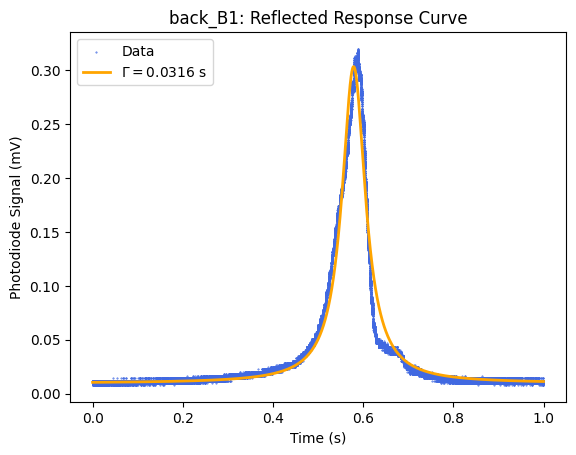

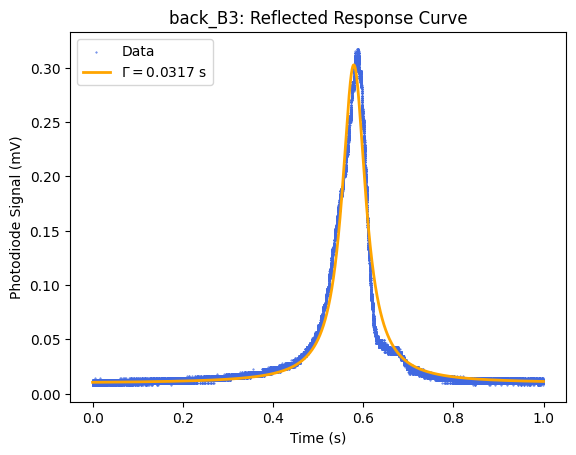

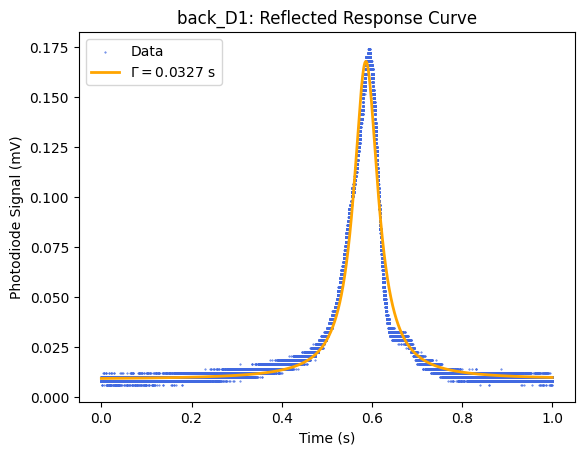

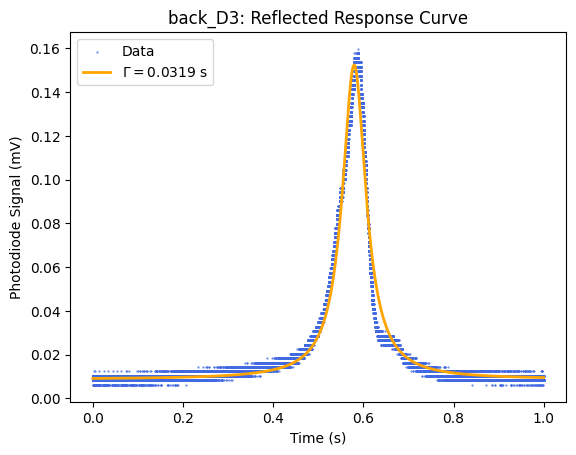

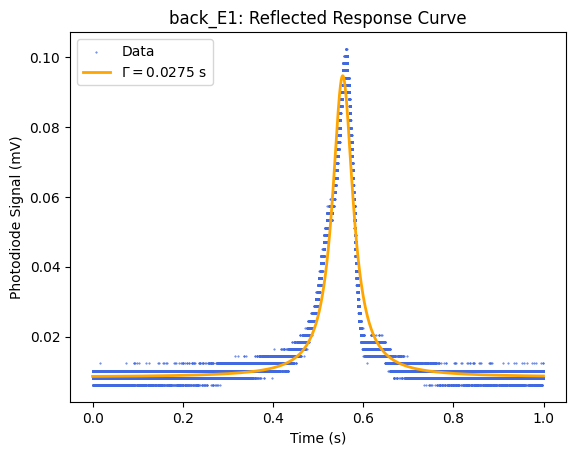

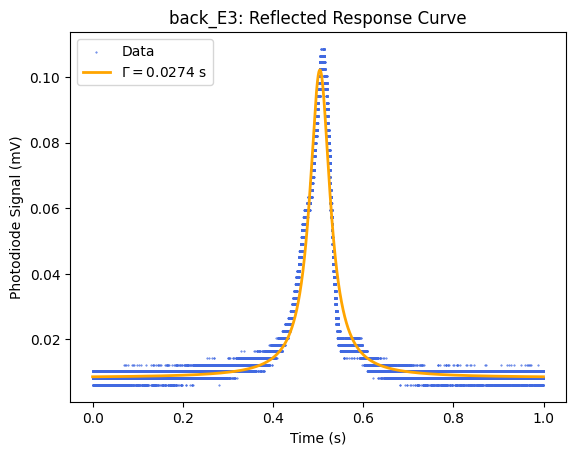

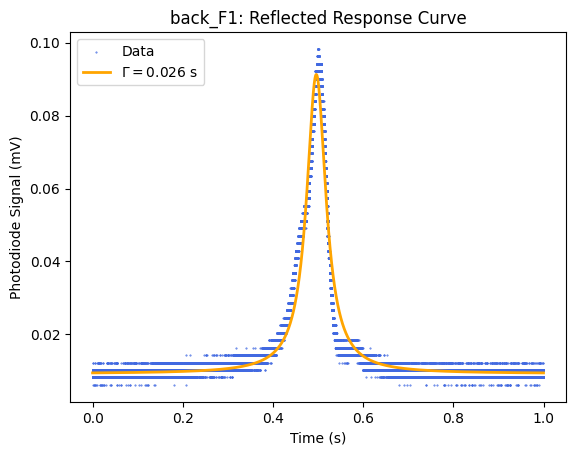

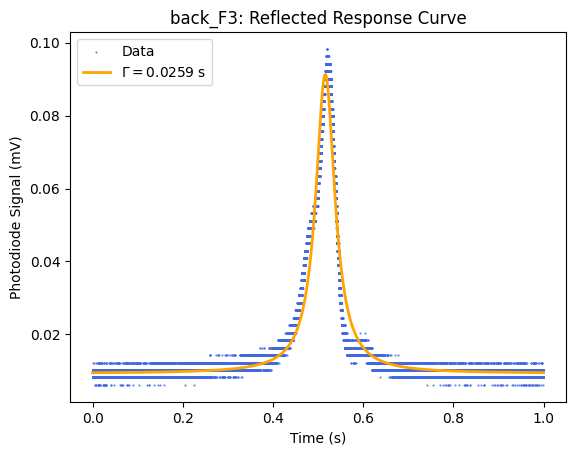

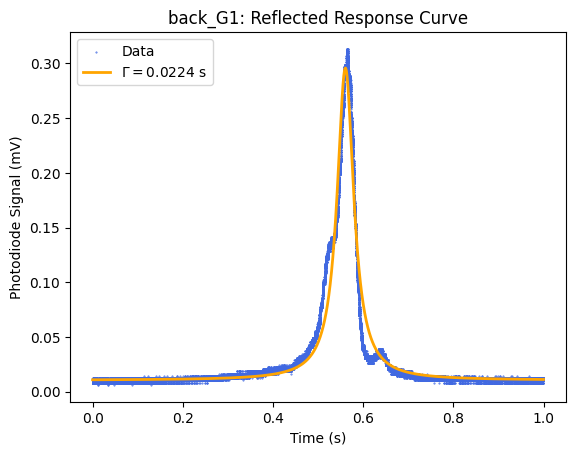

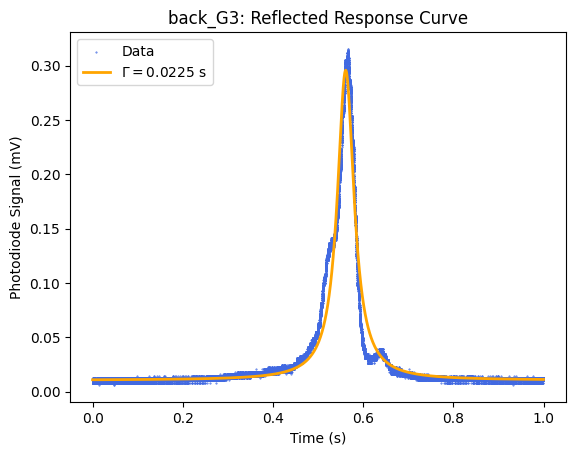

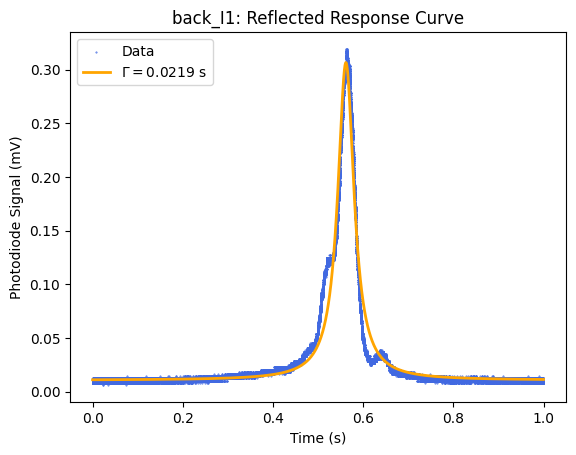

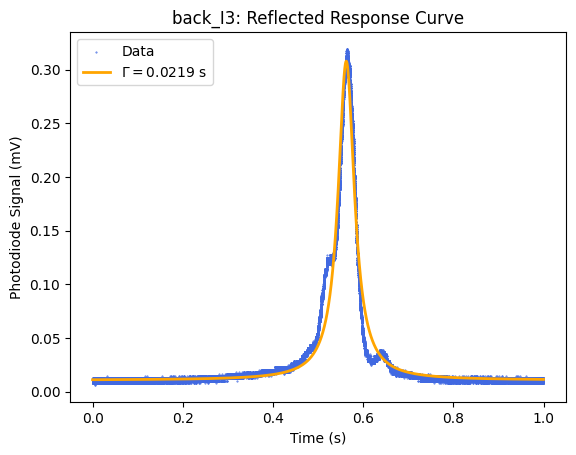

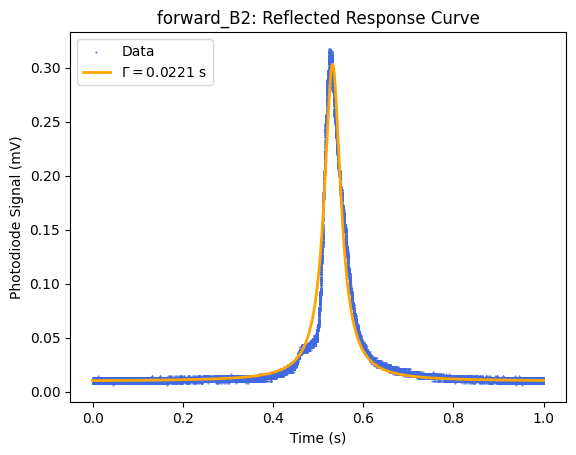

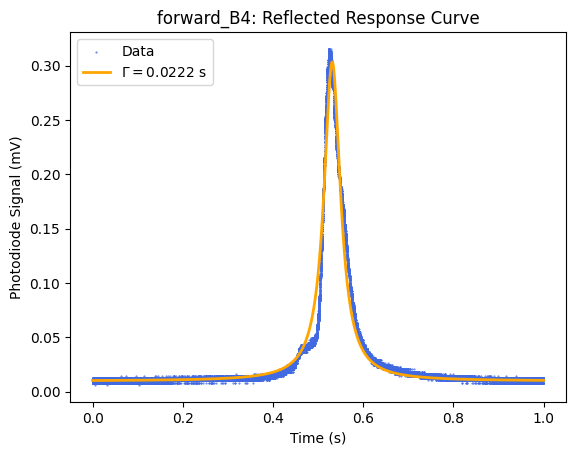

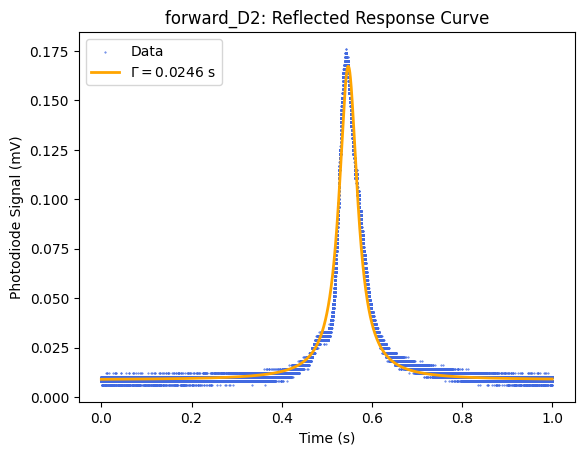

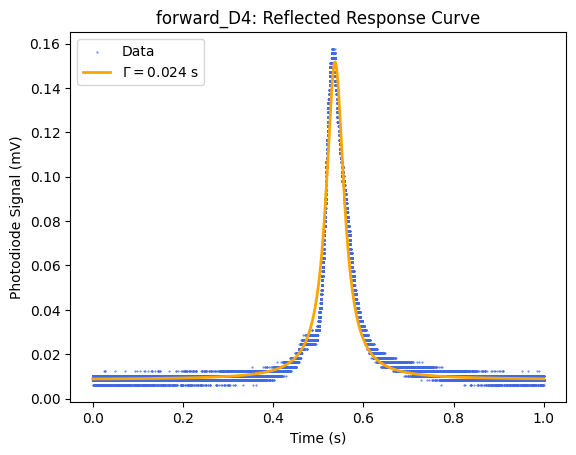

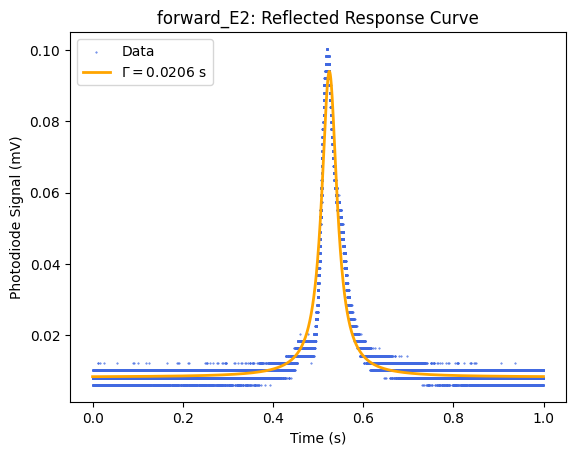

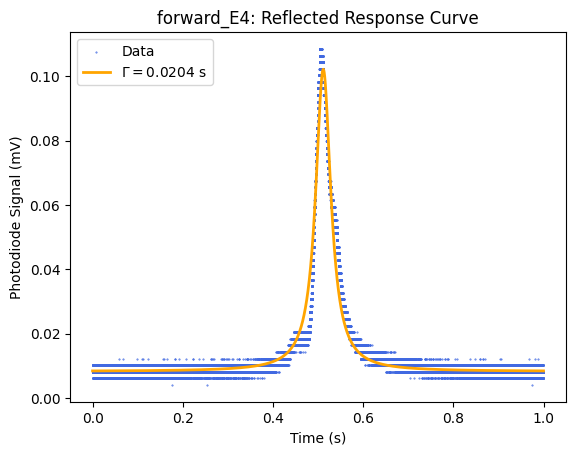

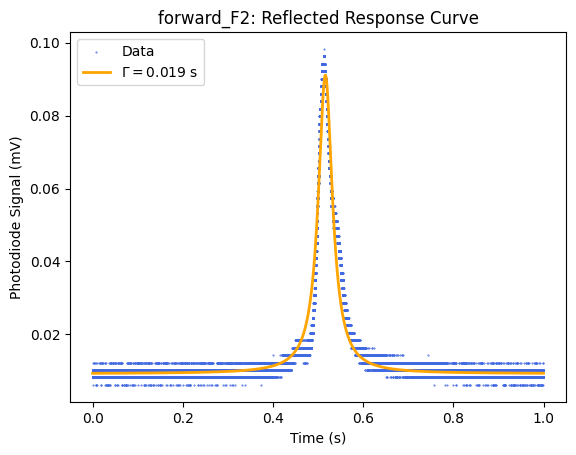

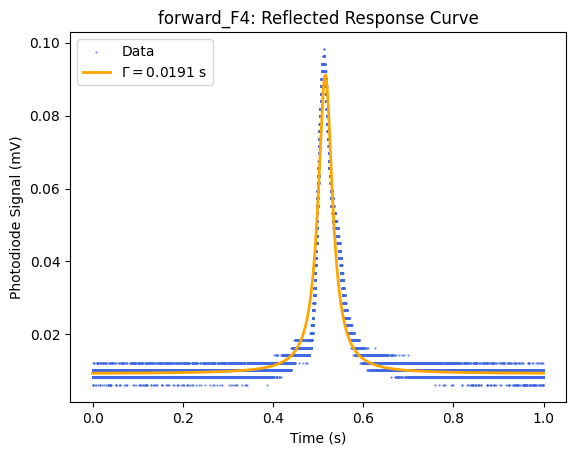

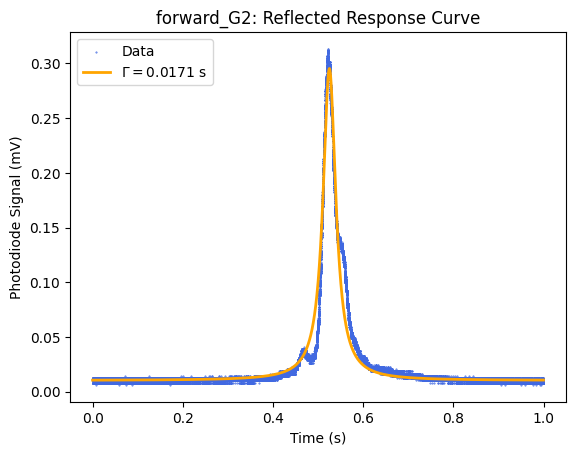

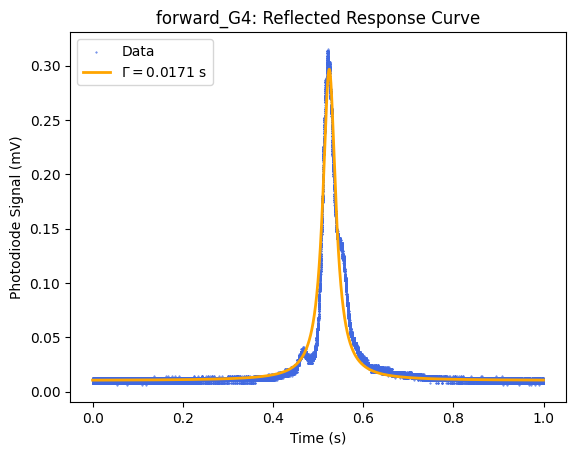

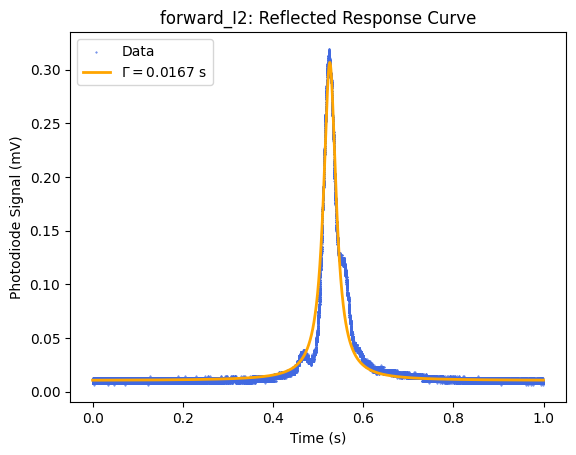

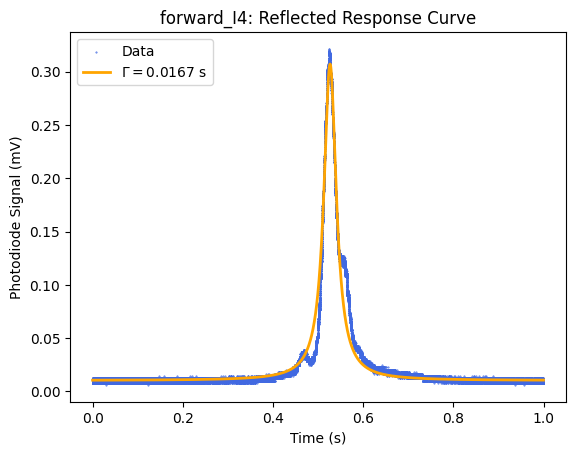

In [ ]:
# grab all CSV files inside back/400Hz/<config>/<date>/folders with full path
back_files = glob.glob("back/400Hz/config 2/*/*.csv")

# grab all CSV files inside forward/400Hz/<config>/<date>/folders with full path
forward_files = glob.glob("forward/400Hz/config 2/*/*.csv")

# initialise arrays for data storage
FWHM_back_400Hz_config_2 = np.zeros((len(back_files), 6))
FWHM_forward_400Hz_config_2 = np.zeros((len(forward_files), 6))
IDs_400Hz_config_2 = []

for i, file in enumerate(back_files):
    ID, duration, steps, dist_back, dist_forward, sd_duration, amplitude = lorentzian_fitting(file, 800, plot = True)
    IDs_400Hz_config_2.append(ID)
    FWHM_back_400Hz_config_2[i, 0] = duration
    FWHM_back_400Hz_config_2[i, 1] = sd_duration
    FWHM_back_400Hz_config_2[i, 2] = steps
    FWHM_back_400Hz_config_2[i, 3] = dist_back
    FWHM_back_400Hz_config_2[i, 4] = dist_forward
    FWHM_back_400Hz_config_2[i, 5] = amplitude

for i, file in enumerate(forward_files):
    ID, duration, steps, dist_back, dist_forward, sd_duration, amplitude = lorentzian_fitting(file, 800, plot = True)
    IDs_400Hz_config_2.append(ID)
    FWHM_forward_400Hz_config_2[i, 0] = duration
    FWHM_forward_400Hz_config_2[i, 1] = sd_duration
    FWHM_forward_400Hz_config_2[i, 2] = steps
    FWHM_forward_400Hz_config_2[i, 3] = dist_back
    FWHM_forward_400Hz_config_2[i, 4] = dist_forward
    FWHM_forward_400Hz_config_2[i, 5] = amplitude

FWHM_400Hz_config_2 = np.vstack((FWHM_back_400Hz_config_2, FWHM_forward_400Hz_config_2))

In [23]:
# Storing values along directory
FWHM_400Hz_config_2_df = pd.DataFrame(FWHM_400Hz_config_2)
FWHM_400Hz_config_2_df.index = IDs_400Hz_config_2
FWHM_400Hz_config_2_df = FWHM_400Hz_config_2_df.rename(columns={0: 'Duration (s)', 
                                          1: r'SD Duration (s)',
                                          2: r'# Steps', 
                                          3: r'B_distance (micron)', 
                                          4: r'F_distance (micron)',
                                          5: r'Amplitude'})
FWHM_400Hz_config_2_df = FWHM_400Hz_config_2_df.sort_index(axis = 0)
FWHM_400Hz_config_2_df.to_csv('FWHM_400Hz_config_2')
display(FWHM_400Hz_config_2_df)

,Duration (s),SD Duration (s),# Steps,B_distance (micron),F_distance (micron),Amplitude
back_B1,0.063293,0.000070,50.634184,13.519327,20.760015,0.293342
back_B3,0.063446,0.000070,50.756509,13.551988,20.810169,0.292993
back_D1,0.065320,0.000062,52.256400,13.952459,21.425124,0.158921
back_D3,0.063758,0.000064,51.006249,13.618669,20.912562,0.143699
back_E1,0.055088,0.000073,44.070351,11.766784,18.068844,0.086319
back_E3,0.054737,0.000071,43.789358,11.691759,17.953637,0.093783
back_F1,0.052046,0.000069,41.636416,11.116923,17.070931,0.082059
back_F3,0.051898,0.000069,41.518376,11.085406,17.022534,0.082024
back_G1,0.044895,0.000058,35.915897,9.589544,14.725518,0.285452
back_G3,0.045054,0.000058,36.043597,9.623640,14.777875,0.285293


### Configuration 3
#### 24/09/2025
with copper parts now!

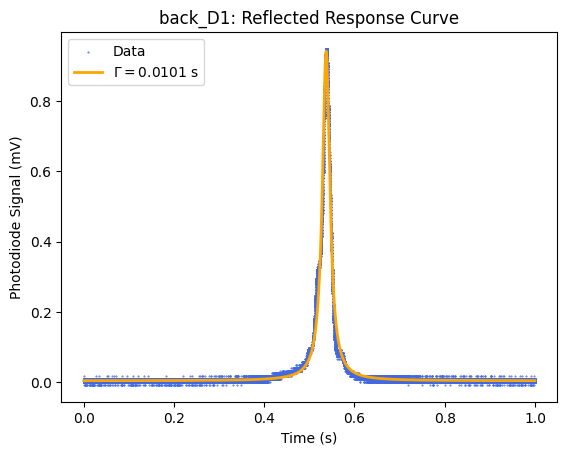

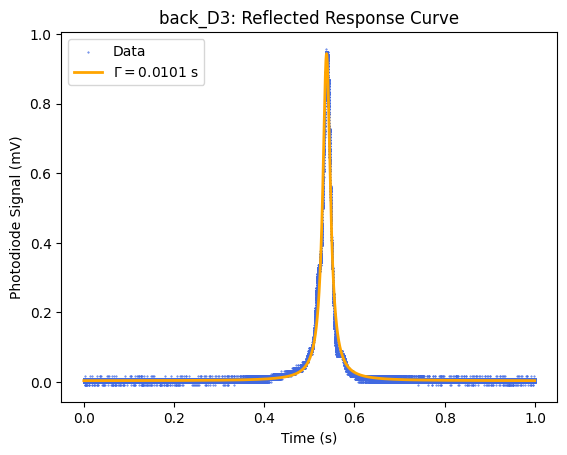

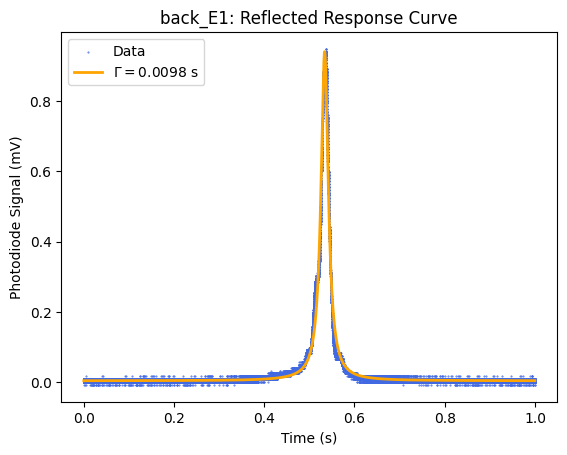

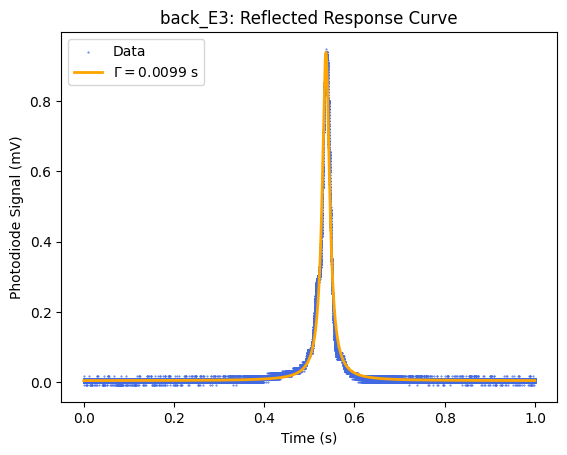

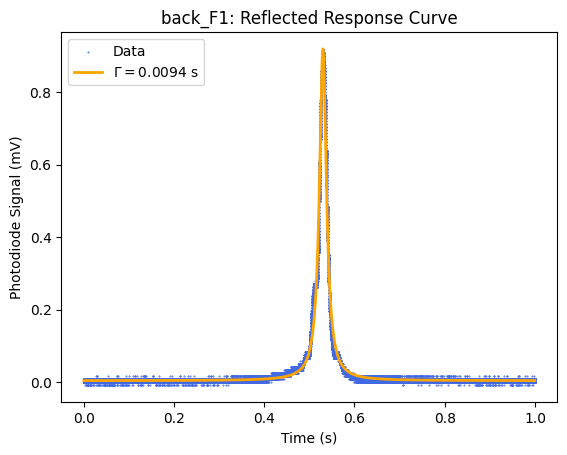

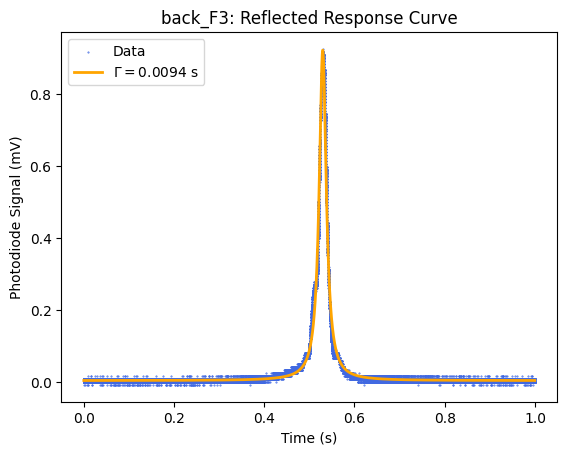

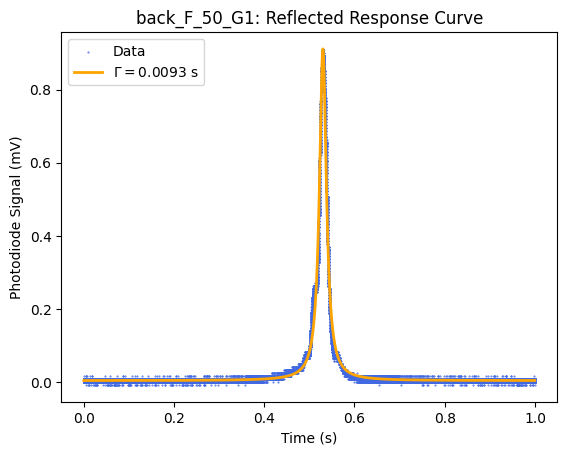

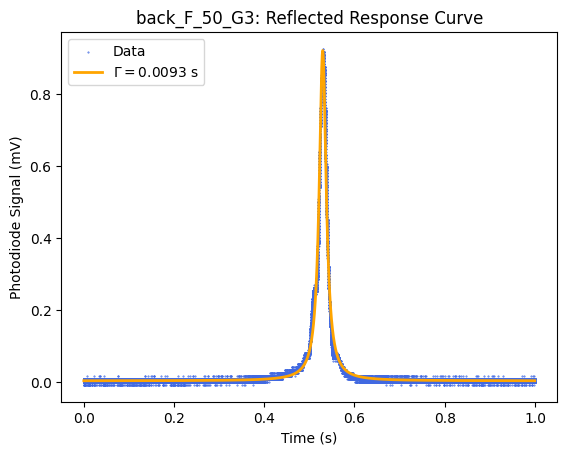

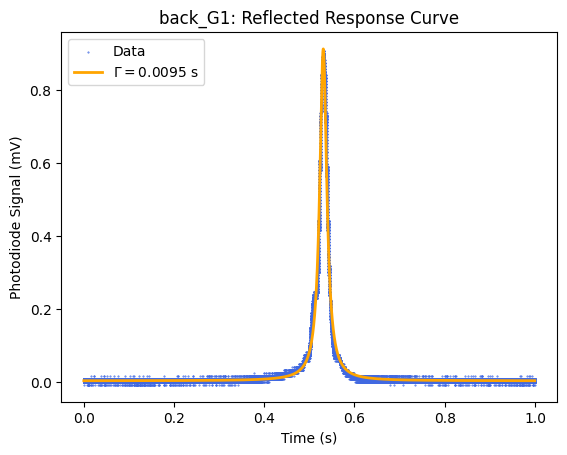

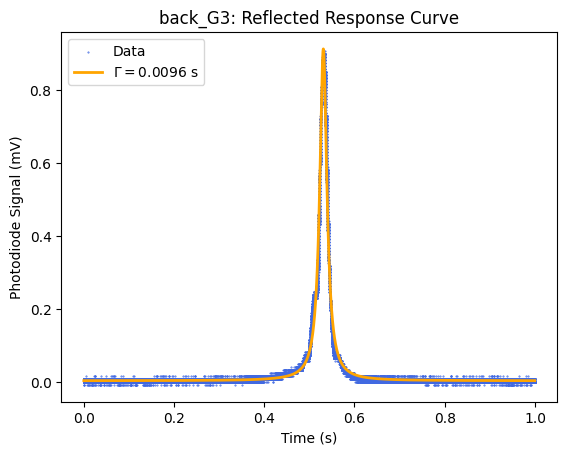

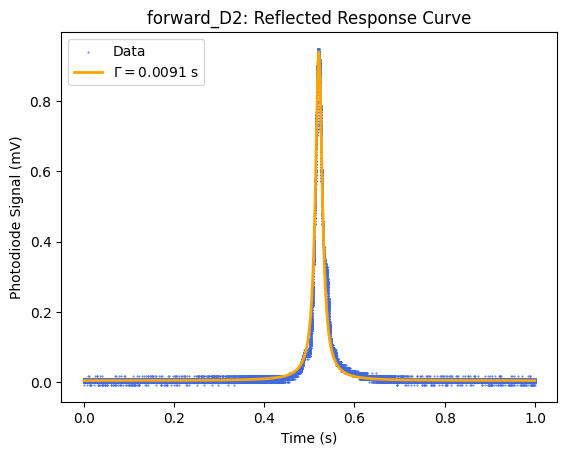

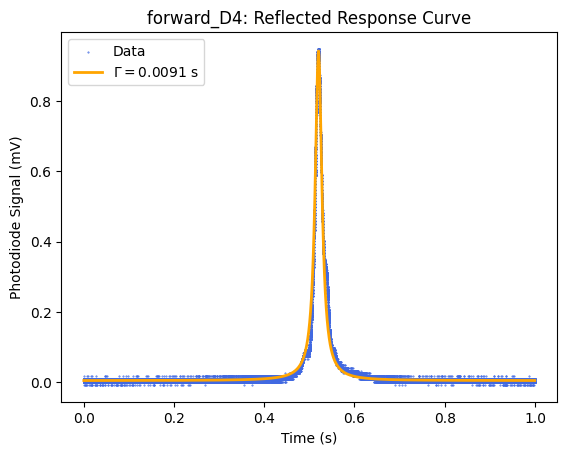

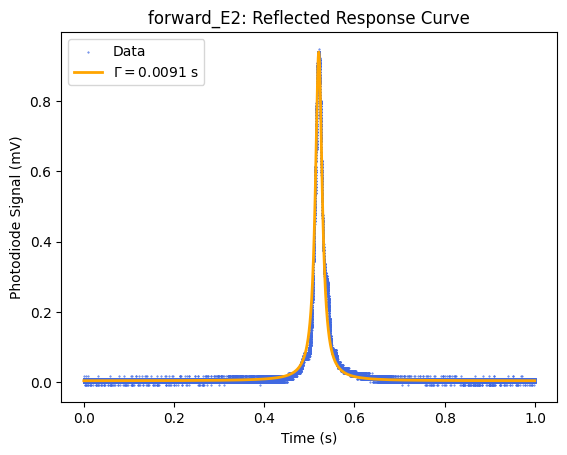

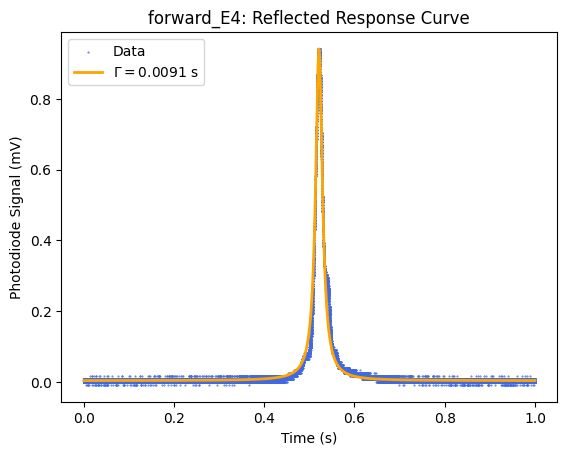

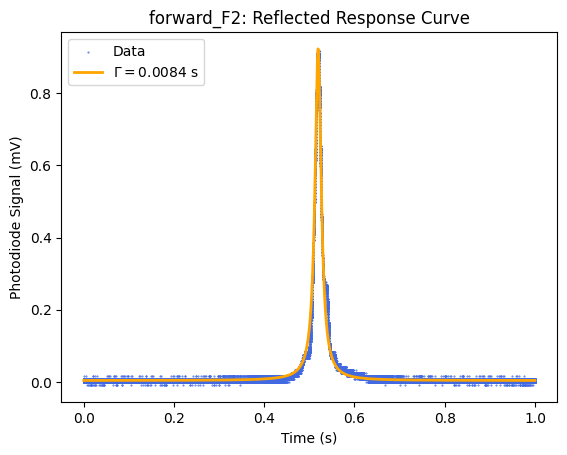

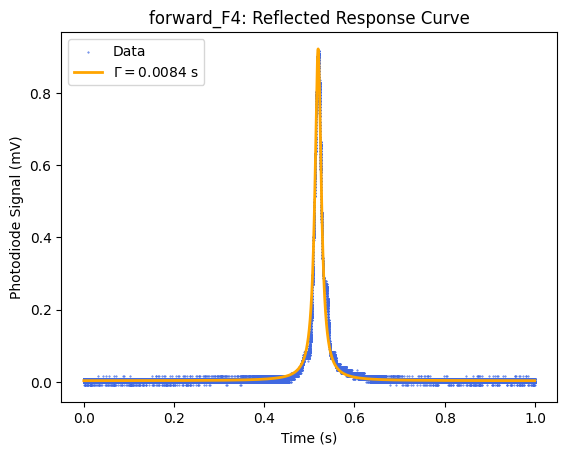

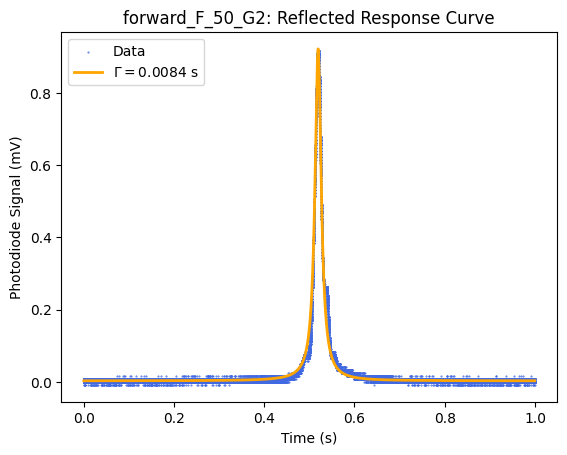

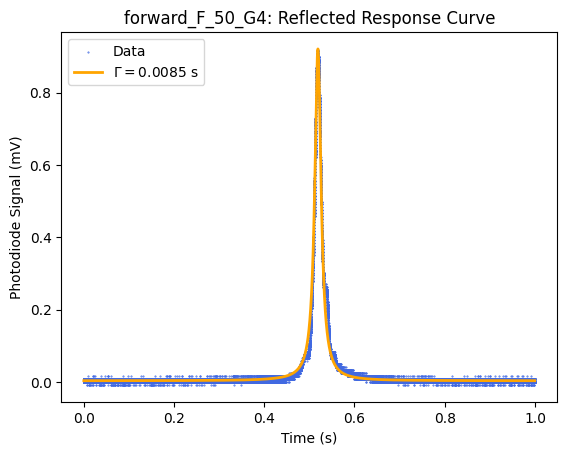

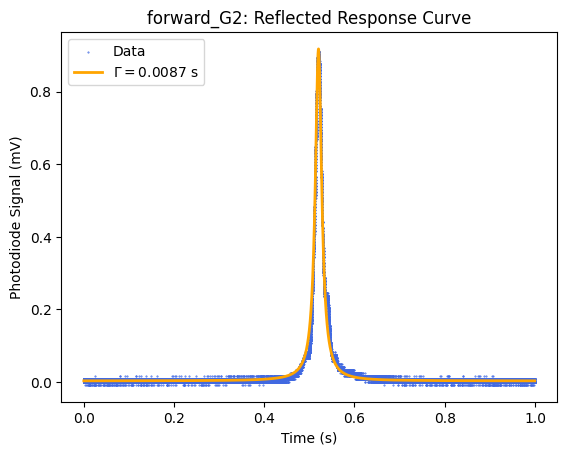

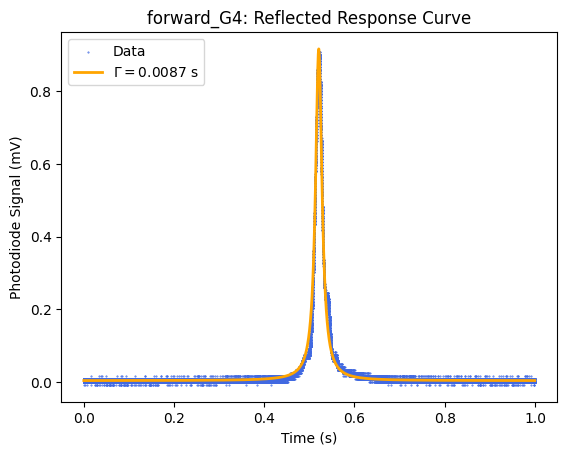

In [ ]:
# grab all CSV files inside back/400Hz/<config>/<date>/folders with full path
back_files = glob.glob("back/400Hz/config 3/*/*.csv")

# grab all CSV files inside forward/400Hz/<config>/<date>/folders with full path
forward_files = glob.glob("forward/400Hz/config 3/*/*.csv")

# initialise arrays for data storage
FWHM_back_400Hz_config_3 = np.zeros((len(back_files), 6))
FWHM_forward_400Hz_config_3 = np.zeros((len(forward_files), 6))
IDs_400Hz_config_3 = []

for i, file in enumerate(back_files):
    ID, duration, steps, dist_back, dist_forward, sd_duration, amplitude = lorentzian_fitting(file, 800, plot = True)
    IDs_400Hz_config_3.append(ID)
    FWHM_back_400Hz_config_3[i, 0] = duration
    FWHM_back_400Hz_config_3[i, 1] = sd_duration
    FWHM_back_400Hz_config_3[i, 2] = steps
    FWHM_back_400Hz_config_3[i, 3] = dist_back
    FWHM_back_400Hz_config_3[i, 4] = dist_forward
    FWHM_back_400Hz_config_3[i, 5] = amplitude

for i, file in enumerate(forward_files):
    ID, duration, steps, dist_back, dist_forward, sd_duration, amplitude = lorentzian_fitting(file, 800, plot = True)
    IDs_400Hz_config_3.append(ID)
    FWHM_forward_400Hz_config_3[i, 0] = duration
    FWHM_forward_400Hz_config_3[i, 1] = sd_duration
    FWHM_forward_400Hz_config_3[i, 2] = steps
    FWHM_forward_400Hz_config_3[i, 3] = dist_back
    FWHM_forward_400Hz_config_3[i, 4] = dist_forward
    FWHM_forward_400Hz_config_3[i, 5] = amplitude

FWHM_400Hz_config_3 = np.vstack((FWHM_back_400Hz_config_3, FWHM_forward_400Hz_config_3))

In [39]:
# Storing values along directory
FWHM_400Hz_config_3_df = pd.DataFrame(FWHM_400Hz_config_3)
FWHM_400Hz_config_3_df.index = IDs_400Hz_config_3
FWHM_400Hz_config_3_df = FWHM_400Hz_config_3_df.rename(columns={0: 'Duration (s)', 
                                          1: r'SD Duration (s)',
                                          2: r'# Steps', 
                                          3: r'B_distance (micron)', 
                                          4: r'F_distance (micron)',
                                          5: r'Amplitude'})
FWHM_400Hz_config_3_df = FWHM_400Hz_config_3_df.sort_index(axis = 0)
FWHM_400Hz_config_3_df.to_csv('FWHM_400Hz_config_3')
display(FWHM_400Hz_config_3_df)

,Duration (s),SD Duration (s),# Steps,B_distance (micron),F_distance (micron),Amplitude
back_D1,-0.020144,0.000017,-16.114943,-4.302690,-6.607127,0.939342
back_D3,-0.020154,0.000017,-16.123466,-4.304965,-6.610621,0.940097
back_E1,-0.019571,0.000016,-15.656509,-4.180288,-6.419169,0.938003
back_E3,-0.019736,0.000017,-15.788650,-4.215569,-6.473346,0.935760
back_F1,0.018749,0.000015,14.998871,4.004699,6.149537,0.916140
back_F3,0.018830,0.000015,15.064382,4.022190,6.176397,0.917462
back_F_50_G1,0.018506,0.000016,14.804687,3.952852,6.069922,0.908172
back_F_50_G3,0.018598,0.000016,14.878375,3.972526,6.100134,0.917111
back_G1,0.019011,0.000016,15.208768,4.060741,6.235595,0.910525
back_G3,0.019168,0.000016,15.334205,4.094233,6.287024,0.910215


### Resolution

In [75]:
# Room temperature measurement - looks like uncertainties are underestimated
step_frequency = 400 # Hz
final_duration = np.array([0.017319324014186368, 0.017366471267717374]) # s
final_duration_sd = np.array([1.3617288826446247e-05, 1.3642909374238398e-05]) # s
dist_step_400Hz = 0.410 # um
dist_step_400Hz_sd = 0.010 # um

axial_resolution = final_duration * step_frequency * dist_step_400Hz * 2
print(axial_resolution)
axial_resolution_sd = axial_resolution * ((dist_step_400Hz_sd/dist_step_400Hz)**2 + (final_duration_sd/final_duration)**2)
print(axial_resolution_sd)
print(np.mean(axial_resolution), np.mean(axial_resolution_sd))

[5.68073828 5.69620258]
[0.00338289 0.0033921 ]
5.688470426232214 0.003387493611061205


In [76]:
# Theoretical values
# discrepancies could be from dispersion relation of lens material - rated 0.55 NA at 780nm but I am looking at IR. 
# Slight deviation to 0.557 NA gives reasonable agreement with measured values 
n_lens = 1.517
n_vac = 1
n_caf = 1.43
wd = 3.05 # mm
NA = 0.55 * 1.5007/1.5112
NA = 0.55
wavelength = np.array([1.500, 1.550]) # um

r_rad = 0.44 * wavelength/NA * 0.82
r_ax = 0.76 * wavelength/(n_vac - np.sqrt(n_vac**2 - NA**2)) * 0.82
print(r_ax)

[5.67111378 5.86015091]


# CaF2 Unannealed